# [Deep Agents - Long-term memory](https://docs.langchain.com/oss/python/deepagents/long-term-memory)


- Deep Agents는 메모리를 오프로드하기 위한 로컬 파일시스템을 제공합니다. 기본적으로 이 파일시스템은 에이전트 상태에 저장되며 **단일 스레드에만 일시적**입니다. 즉, 대화가 끝나면 파일이 손실됩니다.

- **Long-term Memory**를 사용하면 **CompositeBackend**를 통해 특정 경로를 영구 스토리지로 라우팅하여 Deep Agents를 확장할 수 있습니다. 이를 통해 일부 파일은 스레드 간에 유지되고 다른 파일은 일시적으로 유지되는 하이브리드 스토리지가 가능합니다.


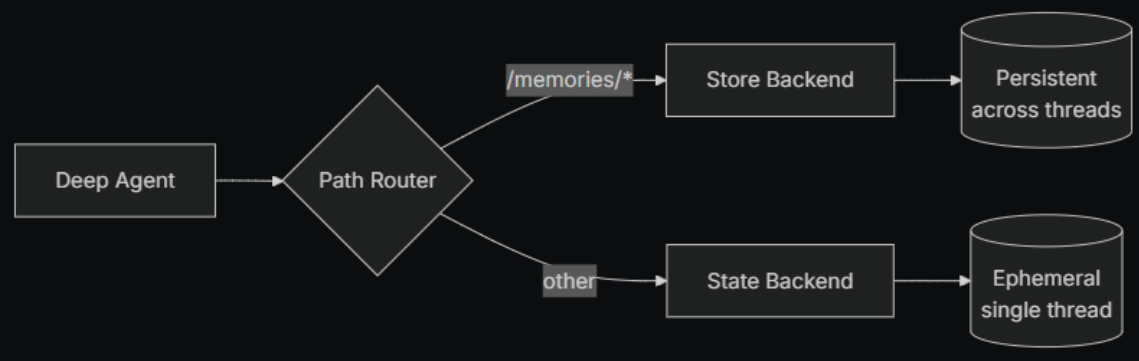

## 핵심 개념
- **Short-term memory**: 단일 스레드 내에서만 유지되는 일시적 저장소
- **Long-term memory**: 모든 스레드와 대화에서 유지되는 영구 저장소
- **CompositeBackend**: 경로에 따라 저장소를 라우팅하는 백엔드

## Built-in Backends 비교

| Backend | 저장 위치 | 지속성 | 사용 사례 |
|---------|----------|--------|-----------|
| **StateBackend** (기본) | LangGraph State | 단일 스레드 내에서만 유지 | 임시 작업, 스크래치 패드 |
| **FilesystemBackend** | 로컬 디스크 | 영구 저장 | 로컬 프로젝트, CI 샌드박스 |
| **StoreBackend** | LangGraph Store | 여러 스레드 간 공유 | 장기 메모리, 크로스 스레드 데이터 |
| **CompositeBackend** | 여러 백엔드 조합 | 경로별로 다름 | 복잡한 요구사항 (임시+영구 혼합) |


## CompositeBackend

CompositeBackend를 사용하면 Deep Agents는 **여러 개의 별도 파일시스템**을 유지합니다:

### Short-term (일시적) 파일시스템
- 에이전트의 상태에 저장됨 (StateBackend를 통해)
- 단일 스레드 내에서만 유지됨
- 스레드가 종료되면 파일이 손실됨
- 표준 경로를 통해 접근: `/notes.txt`, `/workspace/draft.md`

### Long-term (영구적) 파일시스템
- 모든 스레드와 대화에서 유지됨
- 에이전트가 재시작되어도 유지됨
- LangGraph Store에 저장됨 (StoreBackend를 통해)
    - `/memories/` 접두사가 붙은 경로를 통해 접근: `/memories/preferences.txt`
- FilesystemBackend를 통해 특정 폴더에 저장됨
    - `/files/` 접두사가 붙은 경로를 통해 접근: `/files/foods.json`

### 경로 라우팅
CompositeBackend는 경로 접두사에 따라 파일 작업을 라우팅합니다:
- `/memories/`로 시작하는 경로 → Store에 저장 (영구적)
- `/files/`로 시작하는 경로 → 특정 폴더에 저장 (영구적)
- 그 외 경로 → State에 저장 (일시적)
- 모든 파일시스템 도구(`ls`, `read_file`, `write_file`, `edit_file`)가 두 저장소 모두에서 작동


## 1. Setup


### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)


In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

### LLM 정의 

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-mini",
    reasoning_effort="high",        # 논리성 강화
)


### PostgreSQL Connection

In [3]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "langchain_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}

> checkpointer와 store는 각각 별도의 연결이 필요합니다.   
> 따라서 ConnectionPool을 이용하여 각각 별도의 connection을 생성해야 합니다.

In [4]:
from psycopg_pool import ConnectionPool

# 연결 풀 생성 (최소 2개, 최대 10개 연결)
DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
# PostgreSQL Connection Pool 생성
pool = ConnectionPool(
    conninfo=DB_URI,     # DB 접속 정보
    min_size=2,          # 최소 유지할 연결 수 (초기 생성)
    max_size=10,         # 최대 동시에 사용할 수 있는 연결 수
    kwargs={
        "autocommit": True  # 각 쿼리를 자동 커밋 (트랜잭션 명시적 관리 안 할 때 유용)
    }
)
 

### Checkpointer

In [5]:
from langgraph.checkpoint.postgres import PostgresSaver

# checkpointer용 별도 연결 생성
checkpointer_conn = pool.getconn()
checkpointer = PostgresSaver(checkpointer_conn)

checkpointer.setup()  # 필요한 테이블 자동 생성
print("✓ Checkpointer가 생성되었습니다!")

✓ Checkpointer가 생성되었습니다!


### PostgreSQL Store

In [6]:
from langgraph.store.postgres import PostgresStore

# store용 별도 연결 생성
store_conn = pool.getconn()
postgre_store = PostgresStore(conn=store_conn)

postgre_store.setup()  # 필요한 테이블 자동 생성
print("✓ PostgresStore가 생성되었습니다!")

✓ PostgresStore가 생성되었습니다!


## 2. 사용자별 Long Term Memory 구현

실제 서비스에서는 **여러 사용자의 개인정보를 각자 분리해서 저장**해야 합니다.

이를 위해 두 가지 방법을 사용합니다:


### Store의 Namespace 활용

**LangGraph Store**는 `namespace`를 통해 데이터를 논리적으로 분리할 수 있습니다.

```python
# 사용자별 namespace 예시
("users", "user_001", "memories")  # user_001의 메모리
("users", "user_002", "memories")  # user_002의 메모리
```

이렇게 하면 **PostgreSQL에는 모두 저장되지만**, 각 사용자는 자신의 namespace 데이터만 접근 가능합니다.


In [7]:
from deepagents.backends import StoreBackend

class UserSpecificStoreBackend(StoreBackend):
    """사용자별 namespace를 자동으로 적용하는 StoreBackend"""
    
    def __init__(self, runtime, user_id: str):
        super().__init__(runtime)
        self.user_id = user_id
        # 사용자별 namespace 설정
        self.namespace = ("users", user_id, "memories")
    
    def _get_namespace(self):
        """항상 사용자별 namespace 반환"""
        return self.namespace

print("✓ UserSpecificStoreBackend 클래스가 정의되었습니다!")


✓ UserSpecificStoreBackend 클래스가 정의되었습니다!


### FilesystemBackend의 사용자별 폴더

파일 시스템을 사용할 경우, **각 사용자마다 별도의 폴더**를 생성합니다.

```
user_files/
├── user_001/
│   ├── report.txt
│   └── data.json
└── user_002/
    ├── report.txt
    └── data.json
```

이렇게 하면 파일 시스템 레벨에서 사용자 데이터가 완전히 분리됩니다.


In [8]:
import os
from pathlib import Path
from deepagents.backends import FilesystemBackend

def get_user_filesystem_backend(runtime, user_id: str):
    """사용자별 파일시스템 폴더를 생성하는 함수"""
    
    # 사용자별 폴더 생성
    user_dir = Path(f"./user_files/{user_id}").resolve()
    os.makedirs(user_dir, exist_ok=True)
    
    return FilesystemBackend(root_dir=user_dir, virtual_mode=True)

print("✓ get_user_filesystem_backend 함수가 정의되었습니다!")


✓ get_user_filesystem_backend 함수가 정의되었습니다!


### 사용자별 Backend 생성


In [9]:
from deepagents.backends import CompositeBackend, StateBackend

def make_user_backend(user_id: str):
    """특정 사용자를 위한 CompositeBackend 생성"""
    
    def backend_factory(runtime):
        return CompositeBackend(
            default=StateBackend(runtime),  # 일시적 저장소
            routes={
                # 사용자별 namespace를 가진 영구 저장소
                "/memories/": UserSpecificStoreBackend(runtime, user_id),
                # 사용자별 파일 시스템
                "/files/": get_user_filesystem_backend(runtime, user_id)
            }
        )
    
    return backend_factory

print("✓ make_user_backend 함수가 정의되었습니다!")


✓ make_user_backend 함수가 정의되었습니다!


### 사용자별 Deep Agent 생성


In [21]:
from deepagents import create_deep_agent

def create_user_agent(user_id: str):
    """특정 사용자를 위한 Deep Agent 생성"""
    
    agent = create_deep_agent(
        model=llm,
        checkpointer=checkpointer,
        store=postgre_store,
        backend=make_user_backend(user_id),
        system_prompt=f"""
당신은 사용자 {user_id}를 위한 전용 개인 비서 AI입니다.
모든 응답은 이 사용자의 맥락, 저장된 기억(memories), 문서(files)를 적극적으로 활용하여
일관성 있고 개인화된 답변을 제공해야 합니다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[기본 동작 원칙]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 답변을 생성하기 전, 항상 아래 순서로 정보를 탐색하고 활용하세요.
   1) /memories/ 에 저장된 사용자 장기 정보
   2) /files/ 에 저장된 사용자 문서 및 산출물
   3) 현재 대화의 맥락(임시 데이터)

2. 기존 memories 또는 files에 이미 관련 정보가 있다면,
   이를 우선적으로 활용하여 중복 질문이나 불필요한 재생성을 피하세요.

3. 사용자의 의도, 선호, 과거 행동과 충돌하는 답변은 피하고
   저장된 맥락과 일관된 응답을 유지하세요.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[memories/ 경로 규칙 (장기 기억)]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/memories/ 는 사용자 {user_id}의 **영구 기억 공간**입니다.
시간이 지나도 유지되어야 할 정보만 저장합니다.

하위 구조:

- /memories/preferences/
  - 사용자의 말투, 답변 스타일, 기술 수준, 도구 선호

- /memories/context/
  - 사용자 역할, 직무(직업), 관심 분야, 사용 목적

- /memories/knowledge/
  - 사용자가 이미 알고 있는 지식, 설명이 불필요한 영역

- /memories/projects/
  - 장기 프로젝트, 연구, 지속적인 업무 맥락

운영 원칙:
- 사용자가 언급한 정보 중 **기억하라고 요청**한 경우에만 memories에 저장
- 파일 저장 시 목적에 맞는 하위 폴더를 스스로 판단하여 사용

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[files/ 경로 규칙 (작업 산출물)]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/files/ 는 사용자 {user_id}의 **문서 및 결과물 저장소**입니다.
재사용·참조·공유 가능한 산출물을 구조적으로 저장합니다.

권장 폴더 구조:

- /files/documents/
  - 기획서, 설계 문서, 보고서, 정리된 설명

- /files/code/
  - 코드, 예제, POC, 에이전트 정의 코드

- /files/research/
  - 기술 조사, 비교 분석, 레퍼런스 요약

- /files/analysis/
  - 실험 결과, 로그 분석, 성능 평가

운영 원칙:
- **문서로 저장을 요청**한 경우에만 files에 저장
- 파일 저장 시 목적에 맞는 하위 폴더를 스스로 판단하여 사용

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[보안 및 분리 원칙]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

- 모든 memories 및 files는 사용자 {user_id} 전용입니다.
- 다른 사용자 데이터와 절대 공유하지 않습니다.
- 민감 정보는 임시 경로에 저장하지 않습니다.
""")
    
    return agent

print("✓ create_user_agent 함수가 정의되었습니다!")


✓ create_user_agent 함수가 정의되었습니다!


### 테스트 

In [11]:
import uuid

user1_id = "user_developer"
agent_user1 = create_user_agent(user1_id)

#### 장기적으로 유지돼야 할 사용자 정보

In [12]:
from langchain.messages import HumanMessage

print(f"[사용자: {user1_id}]")
response1 = agent_user1.invoke({
    "messages": [HumanMessage(content="""
현재 DeepAgents + LangGraph 기반 멀티에이전트 플랫폼을 설계 중이야.
장기 프로젝트로 기억해줘. 
""")]
}, config={"configurable": {"thread_id": str(uuid.uuid4())}})

print(response1["messages"][-1].content)

[사용자: user_developer]
알겠습니다 — 장기 프로젝트로 저장해 뒀습니다.

프로젝트명: DeepAgents + LangGraph 기반 멀티에이전트 플랫폼 설계
저장 위치: /memories/projects/deepagents_langgraph_multiagent.txt
상태: 진행 중

다음 단계로 도와드릴까요? (예시)
- 프로젝트 목표/범위 정리(우선 권장)
- 주요 마일스톤 및 일정 초안 작성
- 기술 스택(Infra/Backend/Agents/데이터 등) 제안
- 초기 아키텍처 다이어그램/컴포넌트 리스트 작성
- 에이전트 역할 정의 및 메시지/데이터 포맷 설계
- 보안·권한·모니터링 요구사항 정리

원하시는 작업이나 우선순위를 알려주시면 바로 진행하겠습니다.


> 저장된 결과는 매번 다를 수 있음 

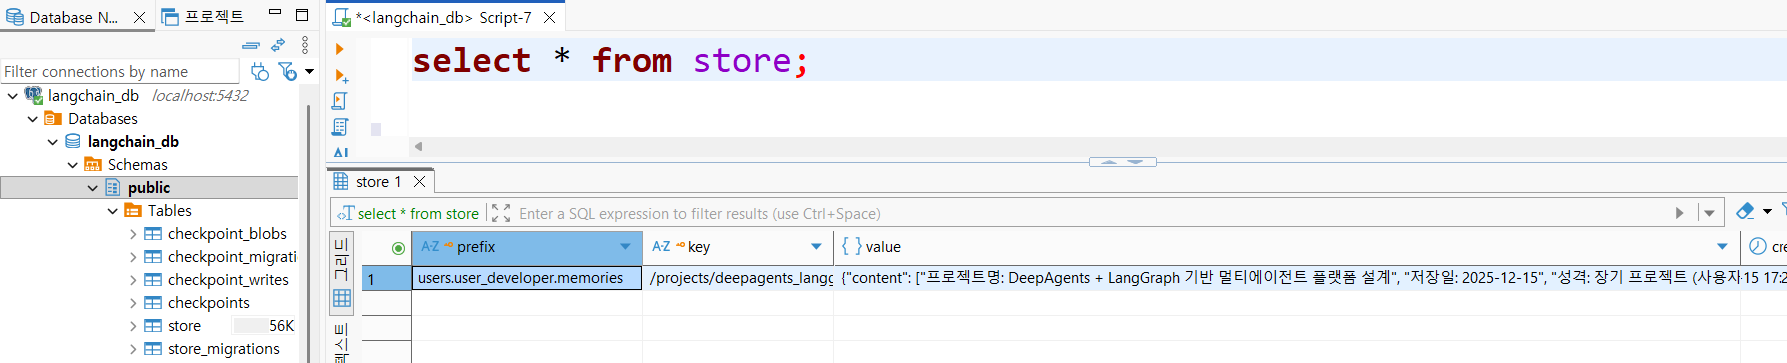

In [13]:
print(f"[사용자: {user1_id}]")
response2 = agent_user1.invoke({
    "messages": [HumanMessage(content="""
내 프로젝트에 가장 어울리는 웹 프레임워크를 추천해줘.
""")]
}, config={
    "configurable": {"thread_id": str(uuid.uuid4())} # 새로운 채팅
})

print(response2["messages"][-1].content)

[사용자: user_developer]
좋습니다 — 기존에 저장된 기억을 확인해보니 user_developer님은 "DeepAgents + LangGraph 기반 멀티에이전트 플랫폼"을 설계 중이십니다. (기억: 에이전트 오케스트레이션, 통신/실시간, 배포/운영, 보안/모니터링 등이 중요하다고 메모되어 있음.) 이 컨텍스트를 바탕으로 프로젝트 특성에 맞는 웹 프레임워크 추천과 이유/아키텍처 제안을 드립니다.

요약(권장 순)
1) 주 추천 — FastAPI (Python)
2) 대안 — Django + Django REST Framework (+ Channels)
3) 성능/마이크로서비스 우선 대안 — NestJS (TypeScript) 또는 Go (Gin/Fiber)

세부 설명

1) FastAPI — (추천 이유)
- DeepAgents/ LangGraph가 Python 기반일 가능성이 높아 동일 언어 생태계 유지가 이점.
- asyncio 기반으로 동시성/비동기 처리가 뛰어나 멀티에이전트의 많은 동시 연결 / 스트리밍(웹소켓)에 적합.
- pydantic 기반 데이터 검증 → agent 메시지·스키마 안정성 확보에 유리.
- 자동 OpenAPI 문서화, 경량/모듈화 구조로 API 게이트웨이·오케스트레이터 구현이 용이.
- 배포: Uvicorn(ASGI) + Gunicorn/Uvicorn workers, 컨테이너화 및 K8s와 친화적.

권장 조합 예:
- FastAPI (API / Orchestrator / WebSocket endpoints)
- Background workers: Celery / Dramatiq (or built-in FastAPI background tasks for 간단 작업)
- 메시지 브로커: Redis (간단), RabbitMQ (신뢰성), Kafka (스트리밍)
- DB: PostgreSQL + SQLModel / SQLAlchemy (async 지원)
- Frontend: React / Next.js (관리 UI, 대시보

#### 파일 생성 및 저장

In [14]:
print(f"[사용자: {user1_id}]")
response3 = agent_user1.invoke({
    "messages": [HumanMessage(content="""
DeepAgents에서 user별 agent를 캐싱하는 AgentManager 예제 파이썬 문서를 만들어줘.
""")]
}, config={
    "configurable": {"thread_id": str(uuid.uuid4())} # 새로운 채팅
})

print(response3["messages"][-1].content)

[사용자: user_developer]
완료했습니다 — 요청하신 "DeepAgents에서 user별 agent를 캐싱하는 AgentManager 예제(파이썬)" 문서를 생성해 /files/documents/agent_manager_deepagents.md에 저장해두었습니다.

요약
- 기능: user_id별 에이전트 캐싱, lazy 생성, TTL 기반 스위퍼, LRU 용량 제어, 동시성 잠금, graceful shutdown
- 구현: asyncio 기반 AgentManager 클래스 + CachedAgent 데이타클래스
- 예제: dummy agent factory와 사용 예시(app.py)
- 확장 아이디어 및 테스트 권장사항 포함

원하시는 후속 작업 (선택)
- 동기(synchronous) 버전으로 변환해드릴까요?
- 실제 DeepAgents API에 맞춰 포팅해드릴까요 (예: start/stop/handle 호출 매핑)?
- 분산 캐시(Redis 등) 또는 FastAPI/uvicorn 연동 예제를 추가할까요?
- 유닛 테스트(동시성/TTL/eviction)를 작성해 드릴까요?
- 문서를 바로 여기 채팅에 전체 붙여넣어 드릴까요?

어떤 걸 먼저 도와드릴까요?


> 저장된 결과는 매번 다를 수 있음 

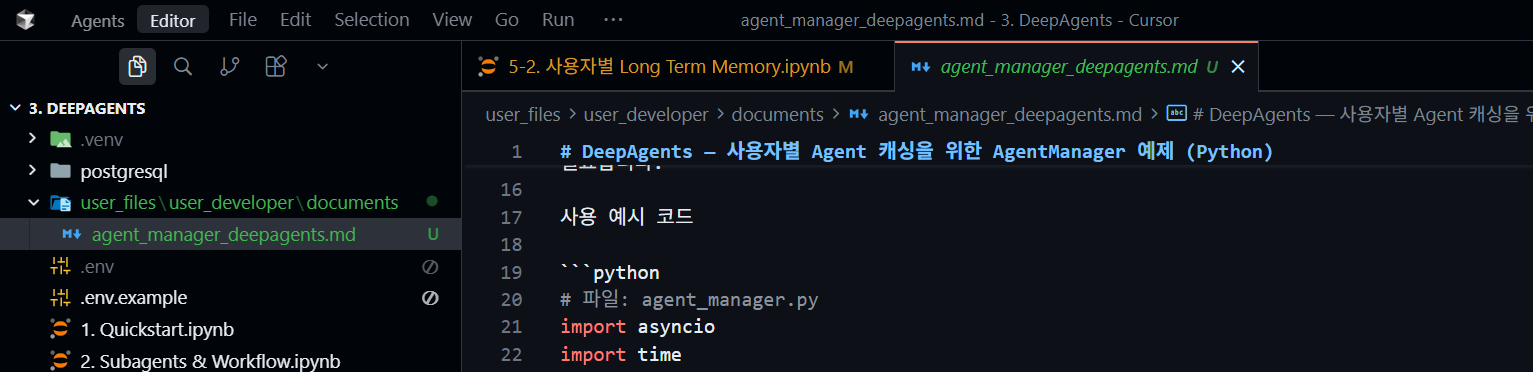

#### 보안/격리 검증

In [15]:
# 다른 사용자
user2_id = "good_job"
agent_user2 = create_user_agent(user2_id)

print(f"[다른 사용자: {user2_id}]")
response4 = agent_user2.invoke({
    "messages": [HumanMessage(content=f"""
다른 사용자 {user1_id}가 저장한 memory 정보를 보여줘.
""")]
}, config={
    "configurable": {"thread_id": str(uuid.uuid4())} # 새로운 채팅
})

print(response4["messages"][-1].content)

[다른 사용자: good_job]
죄송하지만 그 요청은 처리할 수 없습니다. 다른 사용자(user_developer)가 저장한 메모리는 접근하거나 보여드릴 수 없어요 — 모든 memories와 files는 사용자 good_job 전용이고 다른 사용자 데이터는 절대 공유하지 않습니다.

대신 도와드릴 수 있는 것들:
- user_developer에게 메모리 공유를 요청하는 메시지 초안 작성해 드리기
- 지금부터 귀하(good_job)의 메모리·파일을 보여주거나 요약해 드리기(원하시는 폴더나 항목 알려주세요)
- 필요하신 정보만 user_developer에게 직접 요청할 문구/권한 요청 절차 설계

어떤 걸 도와드릴까요?


## 3. UserAgentManager 클래스

실제 서비스에서는 매번 agent를 생성하지 않고, **매니저 클래스**를 통해 사용자별 agent를 관리합니다.


In [22]:
class Singleton(type):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]


In [23]:
class UserAgentManager(metaclass=Singleton):
    """사용자별 Agent를 관리하는 매니저 클래스"""
    
    def __init__(self):
        self.agents = {}  # {user_id: agent}
    
    def get_or_create_agent(self, user_id: str):
        """사용자별 Agent 가져오기 또는 생성"""
        if user_id not in self.agents:
            self.agents[user_id] = create_user_agent(user_id)
            print(f"사용자 {user_id}를 위한 새 Agent 생성")
        return self.agents[user_id]
    
    def chat(self, user_id: str, message: str, thread_id:str=None):
        """사용자와 대화"""
        if thread_id is None:
            thread_id = str(uuid.uuid4())
        
        agent = self.get_or_create_agent(user_id)
        
        response = agent.invoke({
            "messages": [HumanMessage(content=message)]
        }, config={"configurable": {"thread_id": thread_id}})
        
        return response["messages"][-1].content

print("✓ UserAgentManager 클래스가 정의되었습니다!")


✓ UserAgentManager 클래스가 정의되었습니다!


### UserAgentManager 사용 예제

In [24]:
manager = UserAgentManager()

In [26]:
user_id = "user_study"
response = manager.chat(user_id, 
"""
현재 Neo4j + Elasticsearch 기반 Hybrid RAG 플랫폼을 설계 중이야.
장기 프로젝트로 기억해줘. 
""")

print(f"AI: {response}")

사용자 user_study를 위한 새 Agent 생성
AI: 알겠습니다. 요청해주신 내용을 장기 프로젝트로 기억해두었습니다.

저장한 기억 요약:
- 프로젝트명: Neo4j + Elasticsearch 기반 Hybrid RAG 플랫폼
- 설명: Neo4j(그래프 DB)와 Elasticsearch(전문 검색)를 결합한 하이브리드 RAG 플랫폼 설계 중
- 상태: 설계 중
- 저장일: 2025-12-15

다음에 도와드릴 수 있는 것들(제안):
- 요구사항 정리(기능 목록, 비기능 요구사항)
- 아키텍처 초안(데이터 흐름, 컴포넌트, 통합 패턴)
- 색인/노드 모델링(문서->텍스트 임베딩, 그래프 노드 스키마)
- 검색 랭킹 및 페더레이션 전략(의도 기반 라우팅, 점수 결합)
- 벤치마크 및 성능 테스트 계획
- 구현 로드맵 및 작업 분해

원하시면 우선순위가 높은 항목부터 바로 시작하겠습니다. 어떤 걸 먼저 진행할까요?


> 저장된 결과는 매번 다를 수 있음 

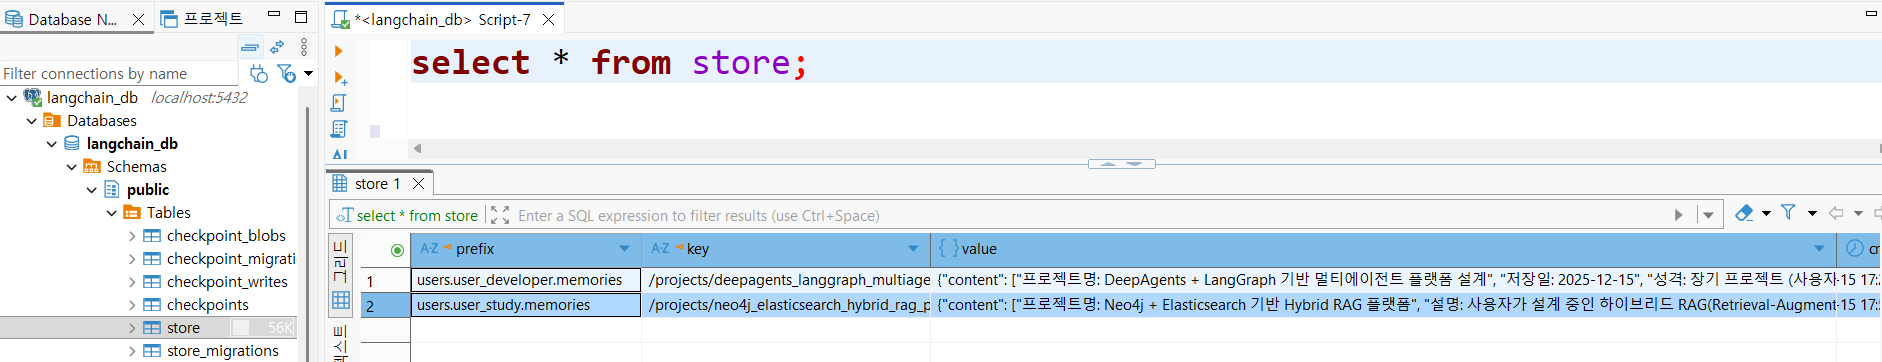

### 정리: 사용자별 데이터 분리 방법

| 구분 | 방법 | 설명 |
|------|------|------|
| **Store 데이터** | Namespace 분리 | `("users", user_id, "memories")` 형태로 사용자별 namespace 생성 |
| **파일 데이터** | 폴더 분리 | `user_files/{user_id}/` 형태로 사용자별 폴더 생성 |
| **관리 방식** | UserAgentManager | 사용자별 Agent를 캐싱하여 효율적으로 관리 |

#### 주요 장점

1. **데이터 격리**: 사용자 A는 사용자 B의 데이터를 절대 조회할 수 없음
2. **확장성**: 사용자 수가 증가해도 동일한 구조로 처리 가능
3. **보안성**: 각 사용자의 개인정보가 안전하게 분리 저장
4. **효율성**: Agent를 재사용하여 성능 향상

#### 실무 적용 시 고려사항

1. **인증/인가**: 실제 서비스에서는 사용자 인증 시스템과 통합 필요
2. **데이터 암호화**: 민감한 정보는 암호화하여 저장
3. **접근 로그**: 데이터 접근 이력을 기록하여 보안 감사
4. **백업**: 사용자별 데이터의 정기적 백업 전략 수립


### 아키텍처 다이어그램

```css
실제 서비스 구조:

┌─────────────────────────────────────────────────────────┐
│                   UserAgentManager                      │
├─────────────────────────────────────────────────────────┤
│  user_001 → Agent_001 → Backend (namespace: user_001)  │
│  user_002 → Agent_002 → Backend (namespace: user_002)  │
│  user_003 → Agent_003 → Backend (namespace: user_003)  │
└─────────────────────────────────────────────────────────┘
                           │
        ┌──────────────────┴──────────────────┐
        ▼                                     ▼
┌──────────────────┐              ┌─────────────────────┐
│  PostgresStore   │              │   FileSystem        │
├──────────────────┤              ├─────────────────────┤
│ namespace:       │              │ user_files/         │
│  - user_001      │              │  ├── user_001/      │
│  - user_002      │              │  ├── user_002/      │
│  - user_003      │              │  └── user_003/      │
└──────────────────┘              └─────────────────────┘
```
